# Evaluating Sternberg Rate Models

Trained ~4/14/26, using `train_interleaved_models.sh` -- longer taus

`python main_interleaved.py --gpu 0 --gpu_frac 0.20 --n_trials 40000 --mode train \
--N 1000 --P_inh 0.20 --som_N 0 --apply_dale True --gain 1.5 --task sternberg \
--load_proportion 0.5 \
--act sigmoid --loss_fn l2 --decay_taus 4 150 --jitter_onset 5 --jitter_delay 3 \
--output_dir ~/Documents/renee/`

jitter onset 5, delay 3. 40k trials. training delay=50.

In [1]:
import os, scipy.io 
import numpy as np 
import matplotlib.pyplot as plt 
import pickle as pk

import sys
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/rate/')
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis/utils')
sys.path.append('/home/nuttidalab/Documents/renee/spikeRNN/analysis')

import model
import generate_rate_data as grd

2026-04-23 14:48:02.418461: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-23 14:48:02.430428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-23 14:48:02.439350: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-23 14:48:02.442067: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-23 14:48:02.450104: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


## already generated data on delay=200 for the N=1000 models

ran the code in `generate_rate_data_v2.ipynb`

In [2]:
import glob

def find_files(path, pattern):
    """
    Find all files matching the given glob pattern in the specified path
    Args:
        path (str): path to directory
        pattern (str): glob pattern (e.g., '*.xlsx', '*_sorted_new.mat')
    Returns:
        list of file paths
    """
    return glob.glob(os.path.join(path, pattern))

In [3]:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = find_files(model_dir, '*N_1000*.mat')
print(len(model_names))
print(model_names)

7
['/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_044205.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_013441.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_061957.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_052959.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_051628.mat', '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5/Task_sternberg_N_1000_Jitter_5_3_2026_04_14_025058.mat']


In [4]:
# the two models with > 0.7 accuracy are:
model_dir = '/home/nuttidalab/Documents/renee/sternberg/interleaved_0.5'

model_names = ['Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533.mat', 
               'Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat']

In [5]:
perfs = []
train_trials = []
for i, model_name in enumerate(model_names):
    model_path = os.path.join(model_dir, model_name)
    model_name = os.path.basename(model_path)
    model_data = scipy.io.loadmat(model_path)
    perfs.append(model_data['eval_perfs'][0])
    train_trials.append(model_data['tr'][0][0])
    print(f'Model: {model_name}, Test perf: {perfs[i]}, Train trials: {train_trials[i]}')


Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_17_174533.mat, Test perf: [0.97 0.98], Train trials: 32201
Model: Task_sternberg_N_1000_Jitter_5_3_2026_04_14_014713.mat, Test perf: [0.96 0.87], Train trials: 25101


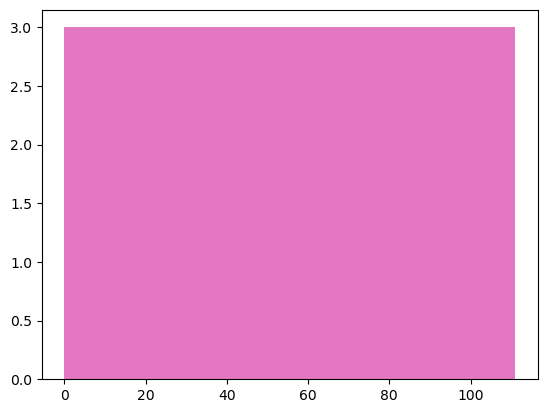

In [ ]:
for model_name in model_names:
    trial_labels, trial_perfs, trial_outputs = ld.load_bhv_rate_data(model_name, condn_phrase, condn_num,
                                                    all_models_dir=all_models_dir)

    stim_ids = trial_labels[:,2:]
    stim_ids = np.nan_to_num(stim_ids, nan=np.inf)
    trial_types, trial_idxs = np.unique(stim_ids, axis=0, return_inverse=True, equal_nan=True)
    match = trial_labels[:,1]
    _ = plt.hist(trial_idxs, bins=112)

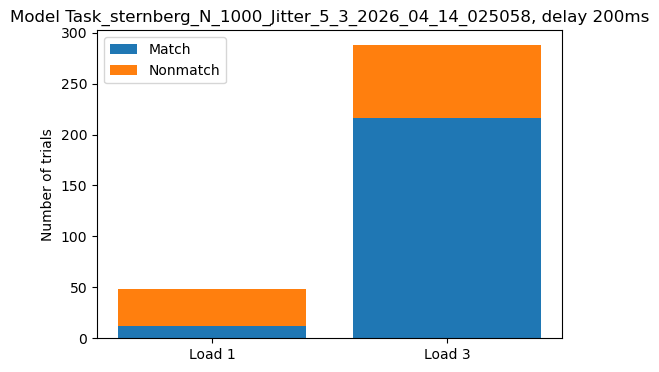

In [ ]:
# how many of stim ids are match vs nonmatch for each load
delay=200
# bar plot of number of match/mismatch for each load
low_match_idx = np.where((trial_labels[:,0] == 1) & (trial_labels[:,1] == 1))[0]
low_nonmatch_idx = np.where((trial_labels[:,0] == 1) & (trial_labels[:,1] == -1))[0]
high_match_idx = np.where((trial_labels[:,0] == 3) & (trial_labels[:,1] == 1))[0]
high_nonmatch_idx = np.where((trial_labels[:,0] == 3) & (trial_labels[:,1] == -1))[0]

plt.figure(figsize=(6,4))
plt.bar(['Load 1', 'Load 3'], [len(low_match_idx), len(high_match_idx)], label='Match')
plt.bar(['Load 1', 'Load 3'], [len(low_nonmatch_idx), len(high_nonmatch_idx)], bottom=[len(low_match_idx), len(high_match_idx)], label='Nonmatch')
plt.ylabel('Number of trials')
plt.title(f'Model {model_name}, delay {delay}ms')
plt.legend()
plt.show()

### model eval

In [6]:
colors = ['#49BEA3', '#6E439A']

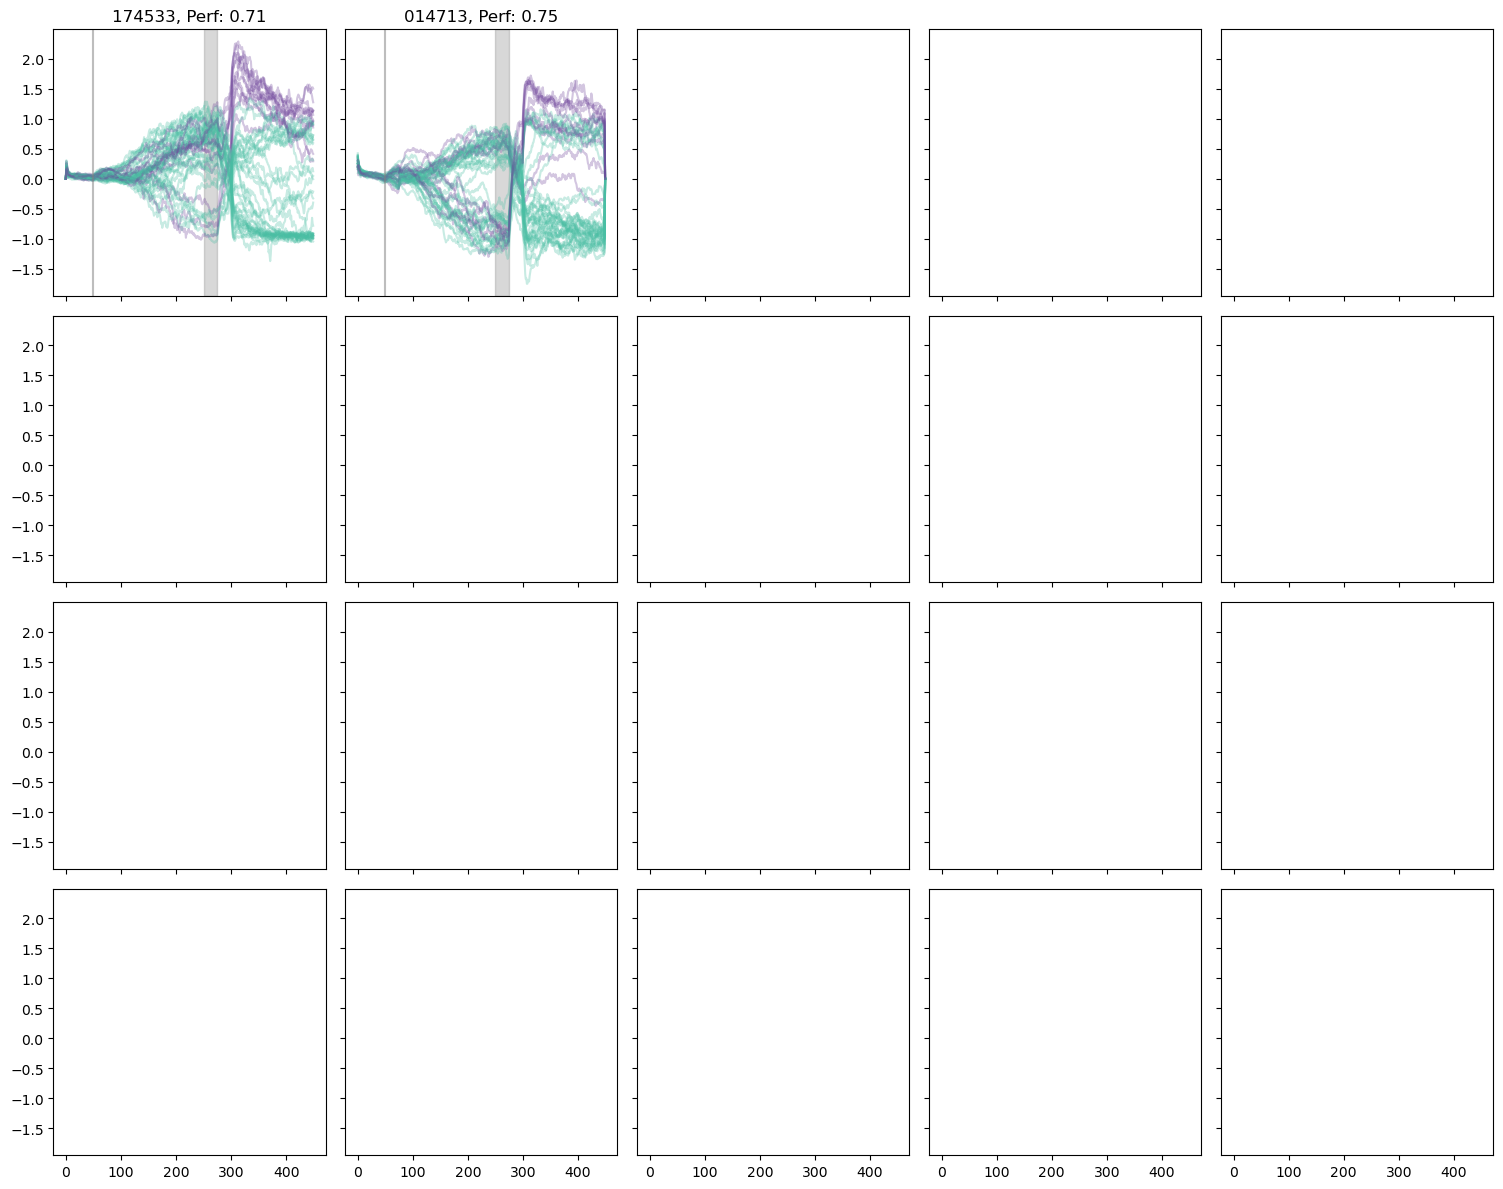

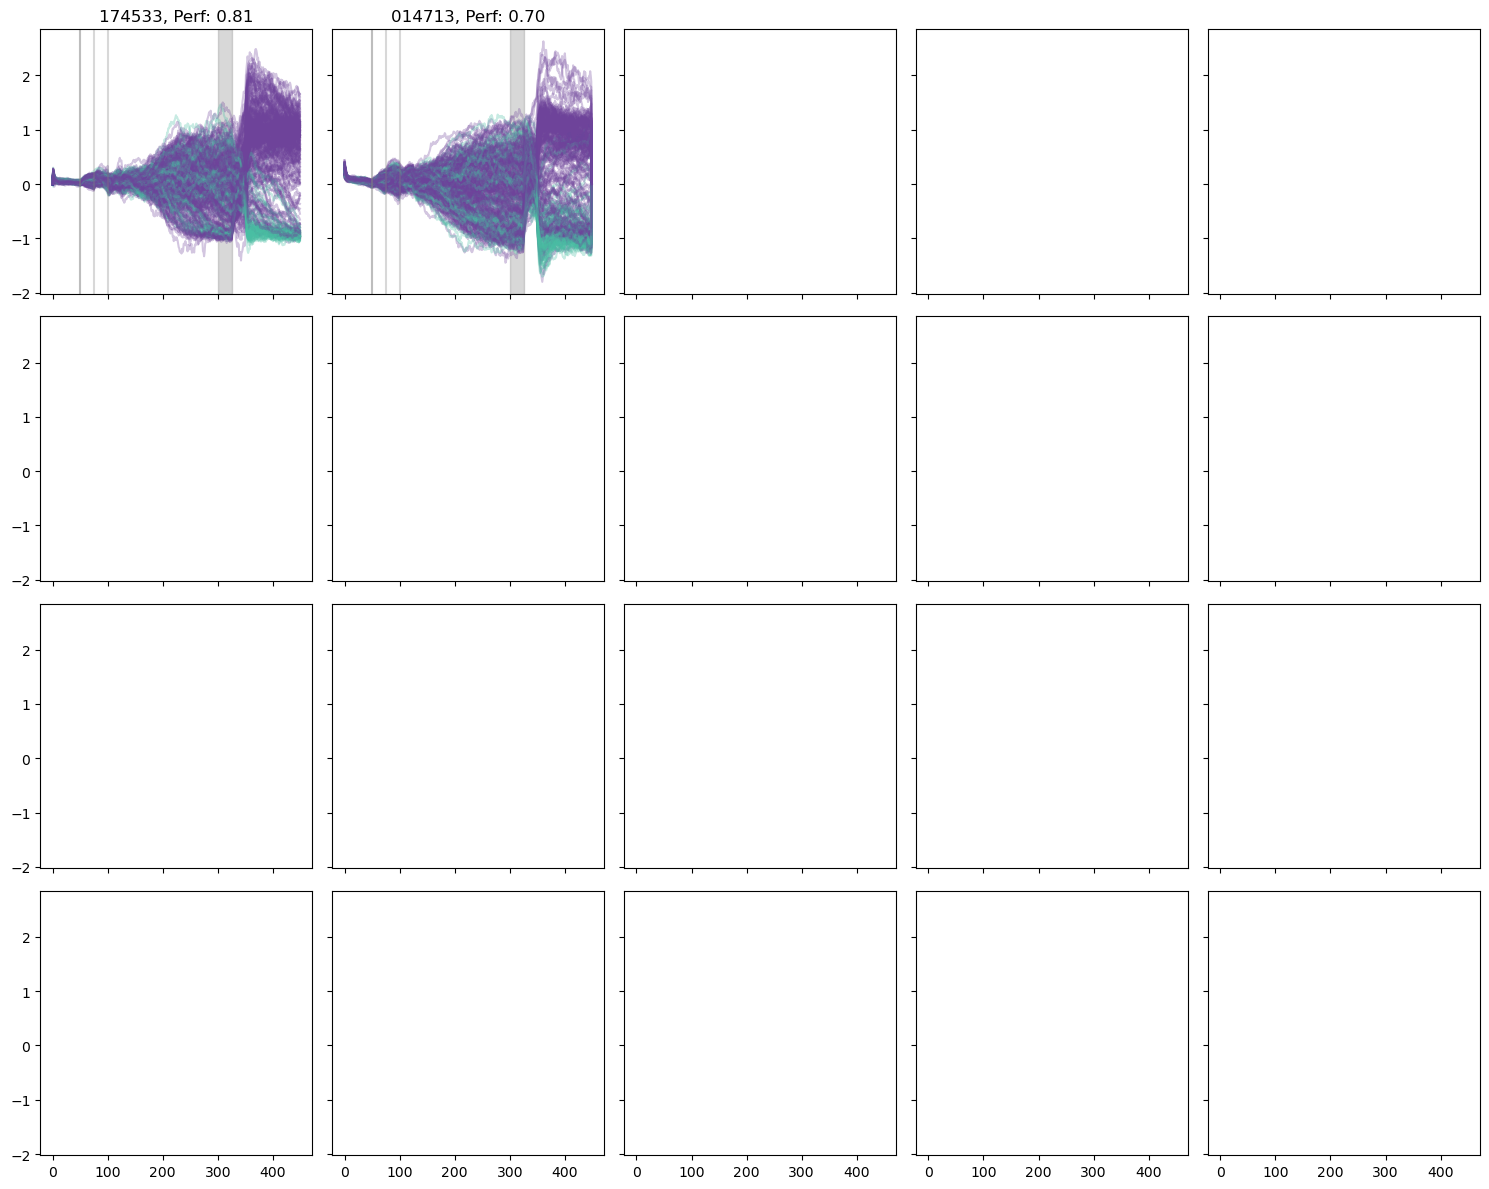

In [7]:
# plot output for each model
settings = {
        'T': 450,
        'stim_on': 50,
        'stim_dur': 25,
        'delay': 200,
        'DeltaT': 1,
        'taus': 20,
        'fs': 200,
        'task': 'sternberg',
        'load': 1,
    }


for k, load in enumerate([1, 3]):
    fig, axs = plt.subplots(4, 5, figsize=(15,12), sharex=True, sharey=True)
    axs = axs.flatten()
    test_perfs = []
    for i, model_path in enumerate(model_names):
        model_name = os.path.basename(model_path)
        output_dir = model_dir + '/' + model_name[:-4] + '/'
        try:
            with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
                bhv_dict = pk.load(f)
            with open(os.path.join(output_dir, f'settings_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
                settings = pk.load(f)
        except:
            print(f'No data for {model_name}, skipping')
            continue
        
        this_load_idx = np.where(np.array(bhv_dict['trial_type'])[:,0] == load)[0]
        for n in this_load_idx:
             axs[i].plot(bhv_dict['outputs'][n], color=colors[int(bhv_dict['trial_type'][n][1] == 1)], alpha=0.3)
        
        axs[i].set_title(f'{model_name[-10:-4]}, Perf: {np.mean(bhv_dict["perf"][this_load_idx]):.2f}')
        test_perfs.append(np.mean(bhv_dict['perf']))
        stim1_on = settings['stim_on']
        axs[i].axvline(stim1_on, color='gray', alpha=0.3)
        for n in range(load):
            stim_on = settings['stim_on'] + n*settings['stim_dur']
            axs[i].axvline(stim_on, color='gray', alpha=0.3)
        axs[i].axvspan(stim_on + settings['delay'], stim_on + settings['delay'] + settings['stim_dur'], color='gray', alpha=0.3)
    plt.tight_layout()
    plt.show()

In [8]:
test_perfs = []
loads = [1, 3]
for i, model_path in enumerate(model_names):
    model_name = os.path.basename(model_path)
    output_dir = model_dir + '/' + model_name[:-4] + '/'
    
    with open(os.path.join(output_dir, f'settings_dict_delay{200}.pkl'), 'rb') as f:
        settings = pk.load(f)
    with open(os.path.join(output_dir, f'bhv_dict_delay{settings["delay"]}.pkl'), 'rb') as f:
        bhv_dict = pk.load(f)
    
    load_perfs = np.zeros(2)
    for n, load in enumerate(loads):
        this_load_idx = np.where(np.array(bhv_dict['trial_type'])[:,0] == load)[0]
        load_perfs[n] = np.mean(bhv_dict['perf'][this_load_idx])
    test_perfs.append(load_perfs)
    
test_perfs = np.array(test_perfs)
test_perfs

array([[0.70833333, 0.80555556],
       [0.75      , 0.70486111]])

/tmp/ipykernel_632741/571410904.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=50', 'Delay=200'])
/tmp/ipykernel_632741/571410904.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=50', 'Delay=200'])
/tmp/ipykernel_632741/571410904.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[2].boxplot([perfs[:,0], perfs[:,1]], labels=['Load 1', 'Load 3'])
/tmp/ipykernel_632741/571410904.py:32: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since 

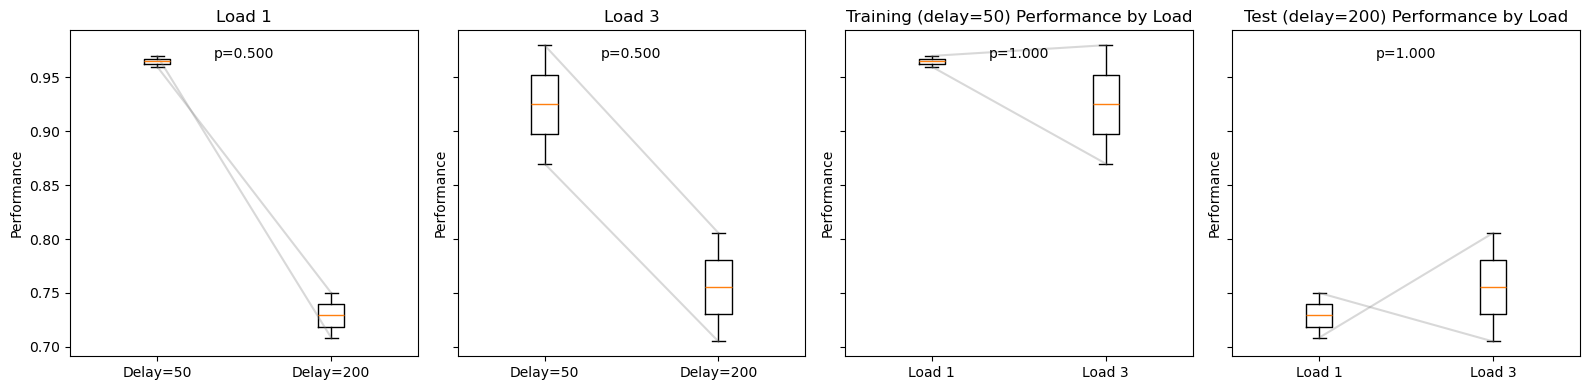

In [9]:
# plot behavior boxplots
perfs = np.array(perfs)
test_perfs = np.array(test_perfs)

fig, axs = plt.subplots(1, 4, figsize=(16,4), sharey=True)

# first compare Training and Test performance for each load
for i, load in enumerate(loads):
    axs[i].boxplot([perfs[:,i], test_perfs[:,i]], labels=['Delay=50', 'Delay=200'])
    axs[i].set_title(f'Load {load}')
    axs[i].set_ylabel('Performance')
    
    # include stats
    from scipy.stats import wilcoxon
    stat, p = wilcoxon(perfs[:,i], test_perfs[:,i])
    axs[i].text(0.5, 0.95, f'p={p:.3f}', transform=axs[i].transAxes, ha='center', va='top')
    
    # gray lines for individual models
    for j in range(perfs.shape[0]):
        axs[i].plot([1, 2], [perfs[j,i], test_perfs[j,i]], color='gray', alpha=0.3)

# next compare training performance across loads
axs[2].boxplot([perfs[:,0], perfs[:,1]], labels=['Load 1', 'Load 3'])
axs[2].set_title('Training (delay=50) Performance by Load')
axs[2].set_ylabel('Performance')
stat, p = wilcoxon(perfs[:,0], perfs[:,1])
axs[2].text(0.5, 0.95, f'p={p:.3f}', transform=axs[2].transAxes, ha='center', va='top')
for j in range(perfs.shape[0]):
    axs[2].plot([1, 2], [perfs[j,0], perfs[j,1]], color='gray', alpha=0.3)

# next compare test performance across loads
axs[3].boxplot([test_perfs[:,0], test_perfs[:,1]], labels=['Load 1', 'Load 3'])
axs[3].set_title('Test (delay=200) Performance by Load')
axs[3].set_ylabel('Performance')
stat, p = wilcoxon(test_perfs[:,0], test_perfs[:,1])
axs[3].text(0.5, 0.95, f'p={p:.3f}', transform=axs[3].transAxes, ha='center', va='top')
for j in range(test_perfs.shape[0]):
    axs[3].plot([1, 2], [test_perfs[j,0], test_perfs[j,1]], color='gray', alpha=0.3)

plt.tight_layout()
plt.show()
    